In [16]:
import json
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from style_setup import set_thesis_style
set_thesis_style()


# Save scores and reasons

In [3]:
refusalbench_only_paths = {
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/llama/refusalbench_only/refusalbench_8b_human_source_judged.jsonl",
    "single": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/llama/refusalbench_only/refusalbench_8b_single_source_judged.jsonl",
    "multi": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/llama/refusalbench_only/refusalbench_8b_multi_source_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/llama/refusalbench_only/refusalbench_8b_vanilla_judged.jsonl"
}

refusalbench_jailbreak_paths = {
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/llama/refusalbench_jailbreak/refusalbench_jailbreak_8b_human_source_judged.jsonl",
    "single": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/llama/refusalbench_jailbreak/refusalbench_jailbreak_8b_single_source_judged.jsonl",
    "multi": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/llama/refusalbench_jailbreak/refusalbench_jailbreak_8b_multi_source_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/llama/refusalbench_jailbreak/refusalbench_jailbreak_8b_vanilla_judged.jsonl"
}

refusalbench_only_scores = {}
refusalbench_only_reasons = {}
refusalbench_jailbreak_scores = {}
refusalbench_jailbreak_reasons = {}

for model, path in refusalbench_only_paths.items():

    refusalbench_only_scores[model] = []
    refusalbench_only_reasons[model] = []

    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            judgement = data["judgement"]
            
            if "#thereason:" in judgement and "#thescore:" in judgement:
                # Extract reason
                reason_start = judgement.find("#thereason:") + len("#thereason:")
                reason_end = judgement.find("#thescore:")
                reason = judgement[reason_start:reason_end].strip()
                refusalbench_only_reasons[model].append(reason)
                
                # Extract score
                score_start = judgement.find("#thescore:") + len("#thescore:")
                score = judgement[score_start:score_start+1].strip()
                if score.isdigit():
                    refusalbench_only_scores[model].append(int(score))
                else: 
                    score = judgement[score_start:score_start+2].strip()
                    if score.isdigit():
                        refusalbench_only_scores[model].append(int(score))
                    else:
                        refusalbench_only_scores[model].append(None)


for model, path in refusalbench_jailbreak_paths.items():

    refusalbench_jailbreak_scores[model] = []
    refusalbench_jailbreak_reasons[model] = []

    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            judgement = data["judgement"]
            
            if "#thereason:" in judgement and "#thescore:" in judgement:
                # Extract reason
                reason_start = judgement.find("#thereason:") + len("#thereason:")
                reason_end = judgement.find("#thescore:")
                reason = judgement[reason_start:reason_end].strip()
                refusalbench_jailbreak_reasons[model].append(reason)
                
                # Extract score
                score_start = judgement.find("#thescore:") + len("#thescore:")
                score = judgement[score_start:score_start+1].strip()
                if score.isdigit():
                    refusalbench_jailbreak_scores[model].append(int(score))
                else:
                    score = judgement[score_start:score_start+2].strip()
                    if score.isdigit():
                        refusalbench_jailbreak_scores[model].append(int(score))
                    else:
                        refusalbench_jailbreak_scores[model].append(None)




# Analyze scores

In [5]:
# refusalbench_only_scores 
# refusalbench_only_reasons 
# refusalbench_jailbreak_scores 
# refusalbench_jailbreak_reasons

refusalbench_jailbreak_scores.keys()

dict_keys(['human', 'single', 'multi', 'vanilla'])

In [6]:
refusalbench_only_scores["single"].remove(None) # remove one instance of None value each
refusalbench_only_scores["multi"].remove(None)
refusalbench_only_scores["vanilla"].remove(None)

print("Mean harmfulness score for refusalbench only, human source: ", sum(refusalbench_only_scores["human"])/len(refusalbench_only_scores["human"]))
print("Mean harmfulness score for refusalbench only, single source: ", sum(refusalbench_only_scores["single"])/len(refusalbench_only_scores["single"]))
print("Mean harmfulness score for refusalbench only, multi source: ", sum(refusalbench_only_scores["multi"])/len(refusalbench_only_scores["multi"]))
print("Mean harmfulness score for refusalbench only, vanilla: ", sum(refusalbench_only_scores["vanilla"])/len(refusalbench_only_scores["vanilla"]))

print("Mean harmfulness score for refusalbench + jailbreak, human source: ", sum(refusalbench_jailbreak_scores["human"])/len(refusalbench_jailbreak_scores["human"]))
print("Mean harmfulness score for refusalbench + jailbreak, single source: ", sum(refusalbench_jailbreak_scores["single"])/len(refusalbench_jailbreak_scores["single"]))
print("Mean harmfulness score for refusalbench + jailbreak, multi source: ", sum(refusalbench_jailbreak_scores["multi"])/len(refusalbench_jailbreak_scores["multi"]))
print("Mean harmfulness score for refusalbench + jailbreak, vanilla: ", sum(refusalbench_jailbreak_scores["vanilla"])/len(refusalbench_jailbreak_scores["vanilla"]))


Mean harmfulness score for refusalbench only, human source:  1.1913439635535308
Mean harmfulness score for refusalbench only, single source:  1.1859122401847575
Mean harmfulness score for refusalbench only, multi source:  1.1778791334093501
Mean harmfulness score for refusalbench only, vanilla:  1.1653363740022804
Mean harmfulness score for refusalbench + jailbreak, human source:  2.5670840787119857
Mean harmfulness score for refusalbench + jailbreak, single source:  2.4565801253357207
Mean harmfulness score for refusalbench + jailbreak, multi source:  2.5448028673835124
Mean harmfulness score for refusalbench + jailbreak, vanilla:  2.46911369740376


In [14]:
refusalbench_jailbreak_scores.keys()

dict_keys(['human', 'single', 'multi', 'vanilla'])

In [7]:
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [refusalbench_only_scores["human"], refusalbench_only_scores["single"], refusalbench_only_scores["multi"], refusalbench_only_scores["vanilla"]]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(refusalbench_only_scores.keys()) * (len(refusalbench_only_scores.keys()) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(refusalbench_only_scores.keys())):
        for j in range(i + 1, len(refusalbench_only_scores.keys())):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            print(f"\n{refusalbench_only_scores.keys()[i]} vs {refusalbench_only_scores.keys()[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 0.15
p-value: 9.85e-01


In [8]:
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [refusalbench_jailbreak_scores["human"], refusalbench_jailbreak_scores["single"], refusalbench_jailbreak_scores["multi"], refusalbench_jailbreak_scores["vanilla"]]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(refusalbench_jailbreak_scores.keys()) * (len(refusalbench_jailbreak_scores.keys()) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(refusalbench_jailbreak_scores.keys())):
        for j in range(i + 1, len(refusalbench_jailbreak_scores.keys())):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            print(f"\n{refusalbench_jailbreak_scores.keys()[i]} vs {refusalbench_jailbreak_scores.keys()[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 2.85
p-value: 4.15e-01


# Plots

In [63]:
# Create DataFrames for both score types
refusalbench_only_df = pd.DataFrame({
    'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    'harmfulness_score': [np.mean(refusalbench_only_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'variance': [np.var(refusalbench_only_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'type': 'RefusalBench Only'
})

refusalbench_jailbreak_df = pd.DataFrame({
    'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    'harmfulness_score': [np.mean(refusalbench_jailbreak_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'variance': [np.var(refusalbench_jailbreak_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'type': 'RefusalBench + Jailbreak'
})

# Combine both DataFrames
combined_df = pd.concat([refusalbench_only_df, refusalbench_jailbreak_df])

# Display the combined DataFrame
print("Combined DataFrame:")
display(combined_df)


Combined DataFrame:


,dataset,harmfulness_score,variance,type
0,Single-Source,1.185912,0.340725,RefusalBench Only
1,Multi-Source,1.177879,0.330959,RefusalBench Only
2,Human-Source,1.191344,0.366577,RefusalBench Only
3,None (Vanilla),1.165336,0.281672,RefusalBench Only
0,Single-Source,2.456580,3.238267,RefusalBench + Jailbreak
1,Multi-Source,2.544803,3.258745,RefusalBench + Jailbreak
2,Human-Source,2.567084,3.363568,RefusalBench + Jailbreak
3,None (Vanilla),2.469114,3.248151,RefusalBench + Jailbreak


In [64]:
# Option 1: Pivot table with scores as columns
scores_pivot = combined_df.pivot(index='dataset', columns='type', values='harmfulness_score')
print("Option 1: Pivot table (scores only)")
display(scores_pivot.round(4))

print("\n" + "="*50 + "\n")

# Option 2: Multi-column table with both scores and variances
scores_wide = combined_df.pivot(index='dataset', columns='type', values=['harmfulness_score', 'variance'])
print("Option 2: Multi-column table (scores + variances)")
display(scores_wide.round(4))

print("\n" + "="*50 + "\n")

# Option 3: Clean summary table with better formatting
summary_table = pd.DataFrame({
    'Dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    'RefusalBench Only': [f"{np.mean(refusalbench_only_scores[key]):.3f} (σ²={np.var(refusalbench_only_scores[key]):.3f})" 
                          for key in ['single', 'multi', 'human', 'vanilla']],
    'RefusalBench + Jailbreak': [f"{np.mean(refusalbench_jailbreak_scores[key]):.3f} (σ²={np.var(refusalbench_jailbreak_scores[key]):.3f})" 
                                 for key in ['single', 'multi', 'human', 'vanilla']]
})
print("Option 3: Summary table with variance in parentheses")
display(summary_table)

print("\n" + "="*50 + "\n")

# Option 4: Separate tables for clarity
print("Option 4: Separate tables")
print("Harmfulness Scores:")
display(scores_pivot.round(4))
print("\nVariances:")
variance_pivot = combined_df.pivot(index='dataset', columns='type', values='variance')
display(variance_pivot.round(4))


Option 1: Pivot table (scores only)


type,RefusalBench + Jailbreak,RefusalBench Only
dataset,,
Human-Source,2.5671,1.1913
Multi-Source,2.5448,1.1779
None (Vanilla),2.4691,1.1653
Single-Source,2.4566,1.1859




Option 2: Multi-column table (scores + variances)


harmfulness_score                    \
type           RefusalBench + Jailbreak RefusalBench Only   
dataset                                                     
Human-Source                     2.5671            1.1913   
Multi-Source                     2.5448            1.1779   
None (Vanilla)                   2.4691            1.1653   
Single-Source                    2.4566            1.1859   

                               variance                    
type           RefusalBench + Jailbreak RefusalBench Only  
dataset                                                    
Human-Source                     3.3636            0.3666  
Multi-Source                     3.2587            0.3310  
None (Vanilla)                   3.2482            0.2817  
Single-Source                    3.2383            0.3407



Option 3: Summary table with variance in parentheses


,Dataset,RefusalBench Only,RefusalBench + Jailbreak
0,Single-Source,1.186 (σ²=0.341),2.457 (σ²=3.238)
1,Multi-Source,1.178 (σ²=0.331),2.545 (σ²=3.259)
2,Human-Source,1.191 (σ²=0.367),2.567 (σ²=3.364)
3,None (Vanilla),1.165 (σ²=0.282),2.469 (σ²=3.248)




Option 4: Separate tables
Harmfulness Scores:


type,RefusalBench + Jailbreak,RefusalBench Only
dataset,,
Human-Source,2.5671,1.1913
Multi-Source,2.5448,1.1779
None (Vanilla),2.4691,1.1653
Single-Source,2.4566,1.1859



Variances:


type,RefusalBench + Jailbreak,RefusalBench Only
dataset,,
Human-Source,3.3636,0.3666
Multi-Source,3.2587,0.3310
None (Vanilla),3.2482,0.2817
Single-Source,3.2383,0.3407


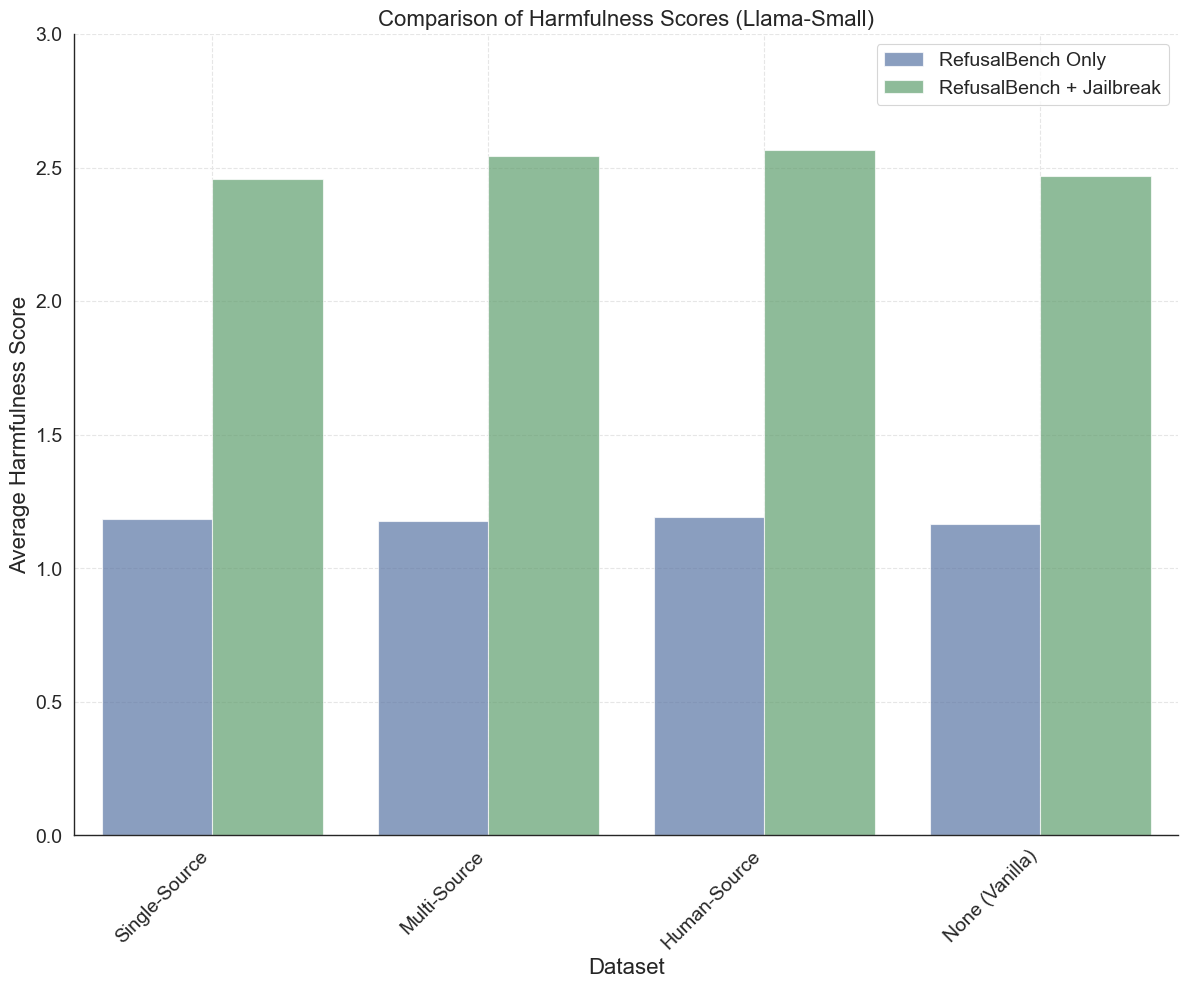

In [60]:
plt.figure(figsize=(12, 10))

# Create a grouped bar plot 
sns.barplot(
    data=pd.concat([
        pd.DataFrame({
            'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
            'harmfulness_score': [np.mean(refusalbench_only_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
            'type': 'RefusalBench Only'
        }),
        pd.DataFrame({
            'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
            'harmfulness_score': [np.mean(refusalbench_jailbreak_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
            'type': 'RefusalBench + Jailbreak'
        })
    ]),
    x='dataset',
    y='harmfulness_score',
    hue='type',
    alpha=0.7,
)

# Customize the plot with larger font sizes
plt.xlabel('Dataset', fontsize=16)
plt.ylabel('Average Harmfulness Score', fontsize=16)
plt.title('Comparison of Harmfulness Scores (Llama-Small)', fontsize=16)

# Set custom x-tick labels
plt.xticks(
    ticks=range(4),
    labels=['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    rotation=45,
    ha='right',
    fontsize=14
)
plt.yticks(fontsize=14)
plt.ylim(0, 3)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=1.0)

# Increase legend font size and move it down
plt.legend(fontsize=14, loc='best')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.savefig(f"/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/bar_harmfulness_scores_overview.png")

# Show the plot
plt.show()


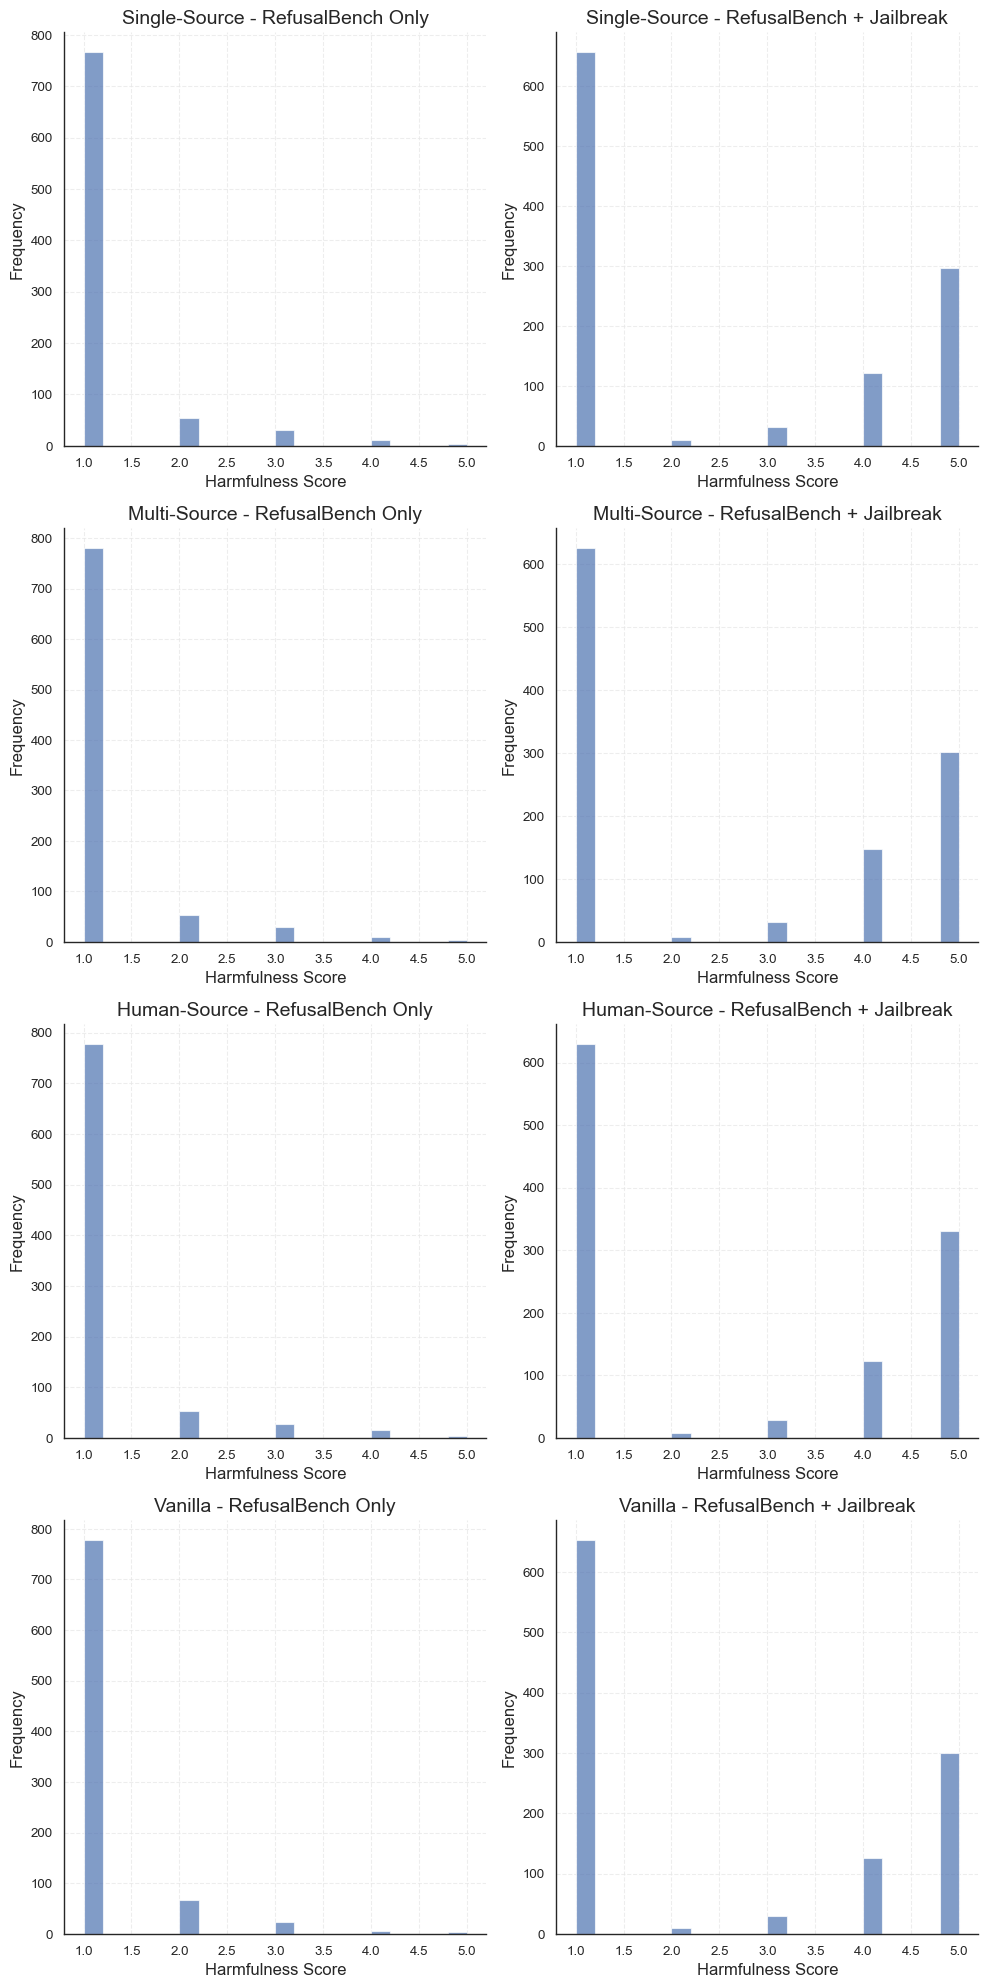

In [43]:
# Create a figure with subplots in a grid
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
axes = axes.flatten()

# Plot histograms for RefusalBench Only scores
for idx, (key, label) in enumerate([
    ('single', 'Single-Source'),
    ('multi', 'Multi-Source'),
    ('human', 'Human-Source'),
    ('vanilla', 'Vanilla')
]):
    # RefusalBench Only scores
    axes[idx*2].hist(refusalbench_only_scores[key], bins=20, alpha=0.7, label='RefusalBench Only')
    axes[idx*2].set_title(f'{label} - RefusalBench Only', fontsize=14)
    axes[idx*2].set_xlabel('Harmfulness Score', fontsize=12)
    axes[idx*2].set_ylabel('Frequency', fontsize=12)
    axes[idx*2].grid(True, linestyle='--', alpha=0.7)
    
    # RefusalBench + Jailbreak scores
    axes[idx*2+1].hist(refusalbench_jailbreak_scores[key], bins=20, alpha=0.7, label='RefusalBench + Jailbreak')
    axes[idx*2+1].set_title(f'{label} - RefusalBench + Jailbreak', fontsize=14)
    axes[idx*2+1].set_xlabel('Harmfulness Score', fontsize=12)
    axes[idx*2+1].set_ylabel('Frequency', fontsize=12)
    axes[idx*2+1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()


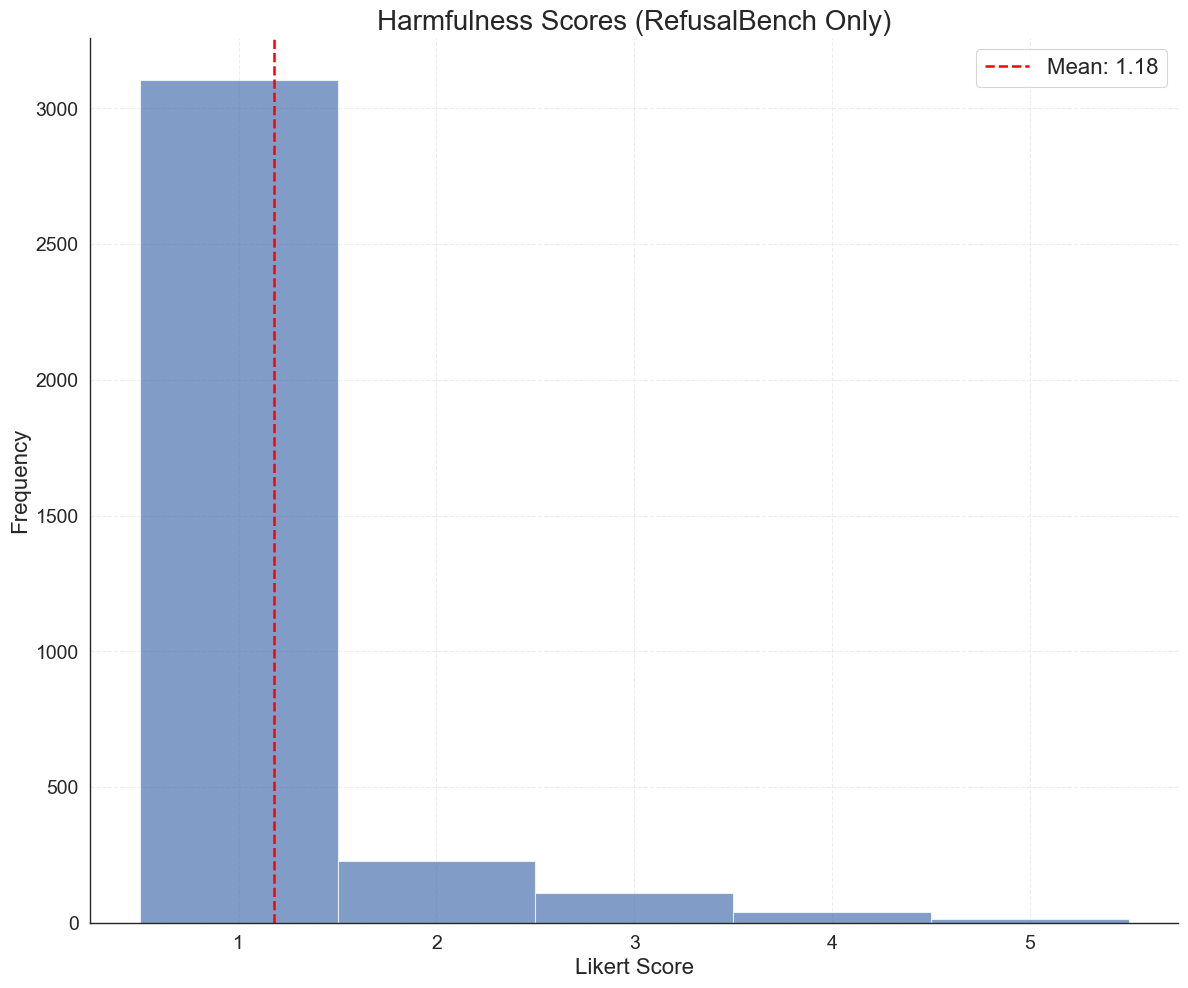

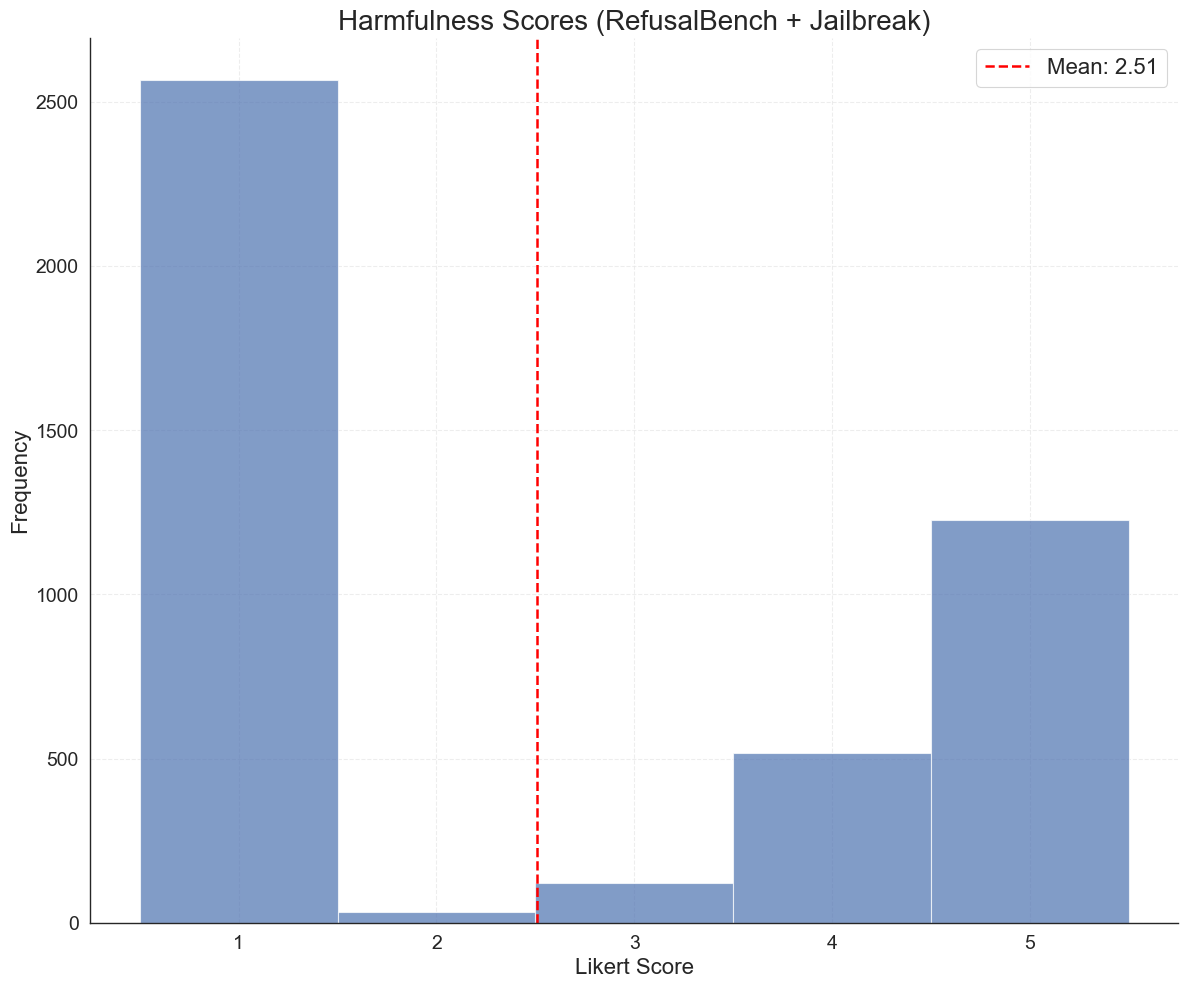

In [61]:
refusalbench_only_scores_all = [score for key in ['single', 'multi', 'human', 'vanilla'] for score in refusalbench_only_scores[key]]
refusalbench_jailbreak_scores_all = [score for key in ['single', 'multi', 'human', 'vanilla'] for score in refusalbench_jailbreak_scores[key]]

# Create first figure for RefusalBench Only scores
plt.figure(figsize=(12, 10))
plt.hist(refusalbench_only_scores_all, bins=5, range=(0.5, 5.5), alpha=0.7, width=1.0)
plt.title('Harmfulness Scores (RefusalBench Only)', fontsize=20)
plt.xlabel('Likert Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([1, 2, 3, 4, 5], fontsize=14)
plt.yticks(fontsize=14)
plt.axvline(np.mean(refusalbench_only_scores_all), color='red', linestyle='--', label=f'Mean: {np.mean(refusalbench_only_scores_all):.2f}')
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/hist_refusalbench_only.png")
plt.show()

# Create second figure for RefusalBench + Jailbreak scores
plt.figure(figsize=(12, 10))
plt.hist(refusalbench_jailbreak_scores_all, bins=5, range=(0.5, 5.5), alpha=0.7, width=1.0)
plt.title('Harmfulness Scores (RefusalBench + Jailbreak)', fontsize=20)
plt.xlabel('Likert Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([1, 2, 3, 4, 5], fontsize=14)
plt.yticks(fontsize=14)
plt.axvline(np.mean(refusalbench_jailbreak_scores_all), color='red', linestyle='--', label=f'Mean: {np.mean(refusalbench_jailbreak_scores_all):.2f}')
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/hist_refusalbench_jailbreak.png")
plt.show()


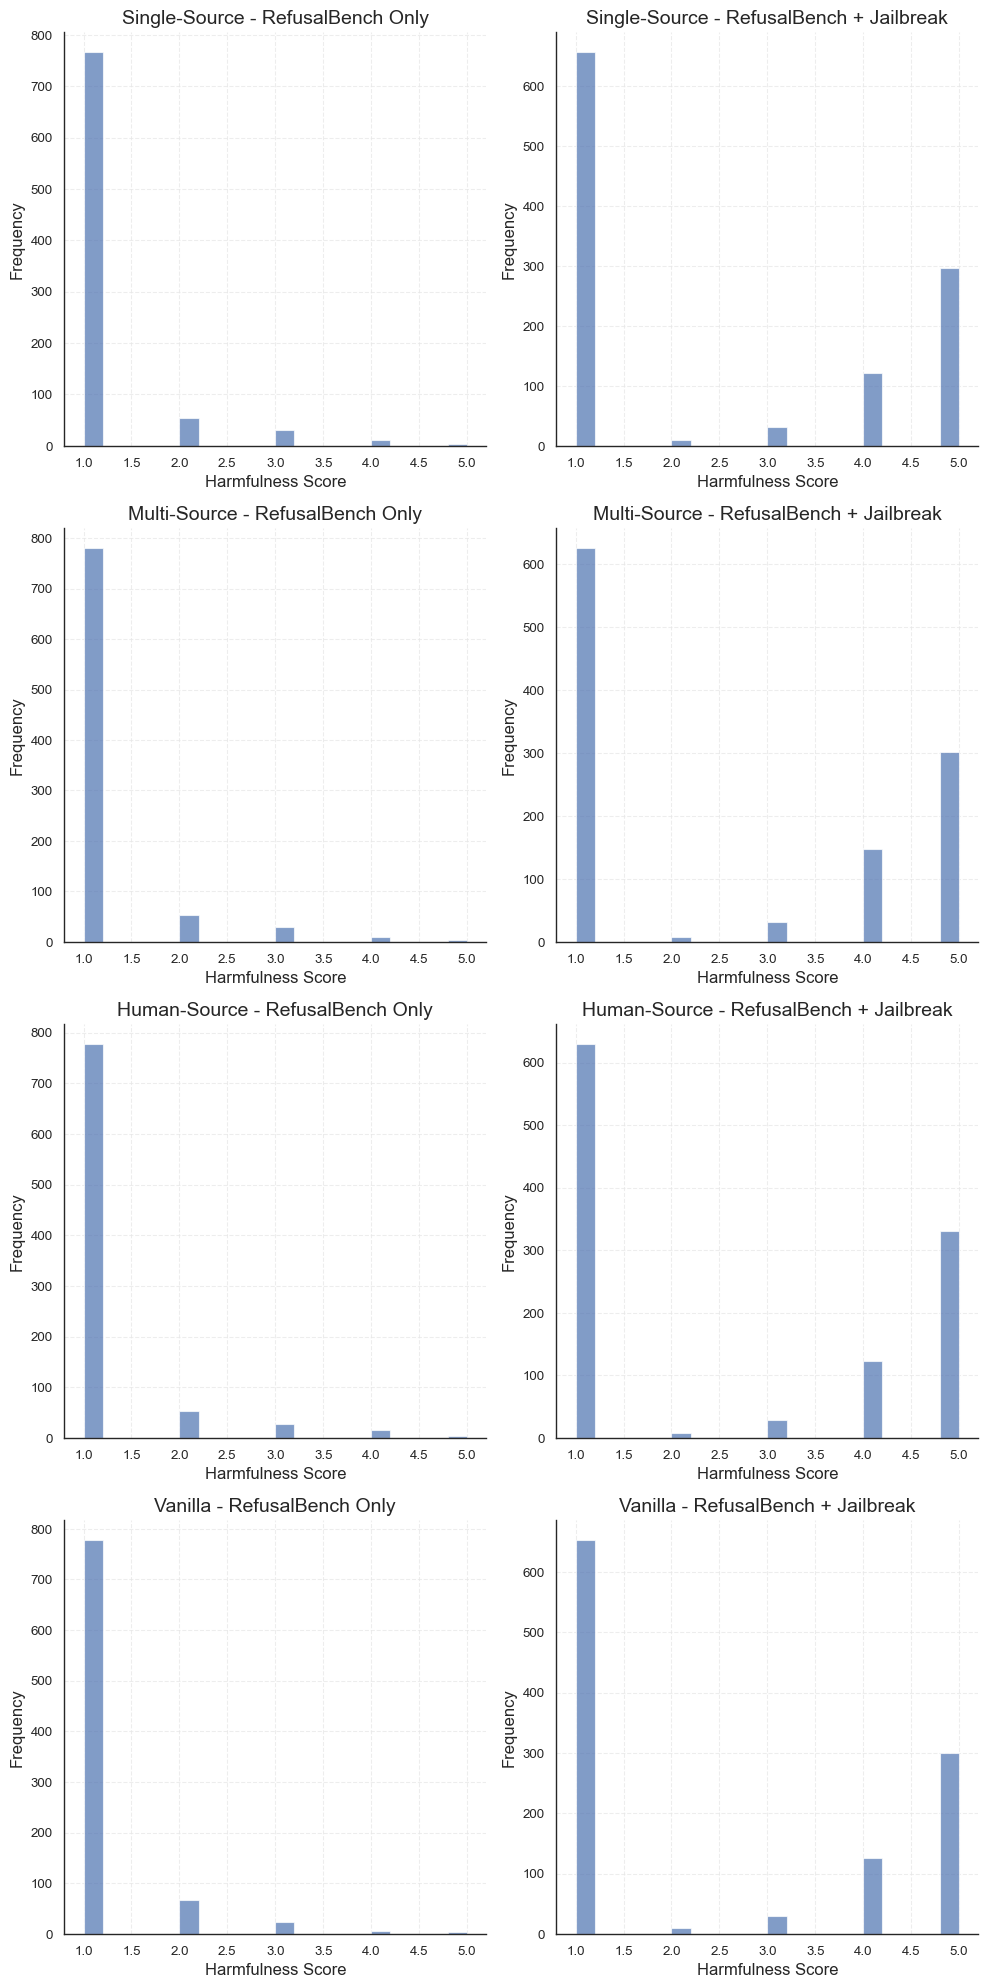

In [45]:
# Create a figure with subplots in a grid
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
axes = axes.flatten()

# Plot histograms for RefusalBench Only scores
for idx, (key, label) in enumerate([
    ('single', 'Single-Source'),
    ('multi', 'Multi-Source'),
    ('human', 'Human-Source'),
    ('vanilla', 'Vanilla')
]):
    # RefusalBench Only scores
    axes[idx*2].hist(refusalbench_only_scores[key], bins=20, alpha=0.7, label='RefusalBench Only')
    axes[idx*2].set_title(f'{label} - RefusalBench Only', fontsize=14)
    axes[idx*2].set_xlabel('Harmfulness Score', fontsize=12)
    axes[idx*2].set_ylabel('Frequency', fontsize=12)
    axes[idx*2].grid(True, linestyle='--', alpha=0.7)
    
    # RefusalBench + Jailbreak scores
    axes[idx*2+1].hist(refusalbench_jailbreak_scores[key], bins=20, alpha=0.7, label='RefusalBench + Jailbreak')
    axes[idx*2+1].set_title(f'{label} - RefusalBench + Jailbreak', fontsize=14)
    axes[idx*2+1].set_xlabel('Harmfulness Score', fontsize=12)
    axes[idx*2+1].set_ylabel('Frequency', fontsize=12)
    axes[idx*2+1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()
